In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
import numpy as np

In [ ]:
corpus = [
     "the king is strong and powerful",
    "the queen is graceful and kind",
    "the prince is young and brave",
    "the princess is intelligent and wise",
    "the ruler is powerful and just",
    "leaders are strong and wise",
    "the man is brave and noble",
    "the woman is kind and intelligent",
    "powerful leaders inspire others",
    "graceful queens are admired",
    "brave warriors lead by example",
    "intelligent people solve problems",
    "wise men and women share knowledge",
    "strong and kind rulers earn respect"
]

In [ ]:
tokenized_sentences = [sentence.lower().split() for sentence in corpus]
tokenized_sentences

[['the', 'king', 'is', 'strong', 'and', 'powerful'],
 ['the', 'queen', 'is', 'graceful', 'and', 'kind'],
 ['the', 'prince', 'is', 'young', 'and', 'brave'],
 ['the', 'princess', 'is', 'intelligent', 'and', 'wise'],
 ['the', 'ruler', 'is', 'powerful', 'and', 'just'],
 ['leaders', 'are', 'strong', 'and', 'wise'],
 ['the', 'man', 'is', 'brave', 'and', 'noble'],
 ['the', 'woman', 'is', 'kind', 'and', 'intelligent'],
 ['powerful', 'leaders', 'inspire', 'others'],
 ['graceful', 'queens', 'are', 'admired'],
 ['brave', 'warriors', 'lead', 'by', 'example'],
 ['intelligent', 'people', 'solve', 'problems'],
 ['wise', 'men', 'and', 'women', 'share', 'knowledge'],
 ['strong', 'and', 'kind', 'rulers', 'earn', 'respect']]

In [ ]:
vocab = Counter(word for sentence in tokenized_sentences for word in sentence)
print(vocab)
vocab_size = len(vocab)
print(vocab_size)

Counter({'and': 10, 'the': 7, 'is': 7, 'strong': 3, 'powerful': 3, 'kind': 3, 'brave': 3, 'intelligent': 3, 'wise': 3, 'graceful': 2, 'leaders': 2, 'are': 2, 'king': 1, 'queen': 1, 'prince': 1, 'young': 1, 'princess': 1, 'ruler': 1, 'just': 1, 'man': 1, 'noble': 1, 'woman': 1, 'inspire': 1, 'others': 1, 'queens': 1, 'admired': 1, 'warriors': 1, 'lead': 1, 'by': 1, 'example': 1, 'people': 1, 'solve': 1, 'problems': 1, 'men': 1, 'women': 1, 'share': 1, 'knowledge': 1, 'rulers': 1, 'earn': 1, 'respect': 1})
40


In [ ]:
word2idx = {word: idx for idx, (word, _) in enumerate(vocab.items())}
word2idx

{'the': 0,
 'king': 1,
 'is': 2,
 'strong': 3,
 'and': 4,
 'powerful': 5,
 'queen': 6,
 'graceful': 7,
 'kind': 8,
 'prince': 9,
 'young': 10,
 'brave': 11,
 'princess': 12,
 'intelligent': 13,
 'wise': 14,
 'ruler': 15,
 'just': 16,
 'leaders': 17,
 'are': 18,
 'man': 19,
 'noble': 20,
 'woman': 21,
 'inspire': 22,
 'others': 23,
 'queens': 24,
 'admired': 25,
 'warriors': 26,
 'lead': 27,
 'by': 28,
 'example': 29,
 'people': 30,
 'solve': 31,
 'problems': 32,
 'men': 33,
 'women': 34,
 'share': 35,
 'knowledge': 36,
 'rulers': 37,
 'earn': 38,
 'respect': 39}

In [ ]:
idx2word = {idx: word for word, idx in word2idx.items()}
idx2word

{0: 'the',
 1: 'king',
 2: 'is',
 3: 'strong',
 4: 'and',
 5: 'powerful',
 6: 'queen',
 7: 'graceful',
 8: 'kind',
 9: 'prince',
 10: 'young',
 11: 'brave',
 12: 'princess',
 13: 'intelligent',
 14: 'wise',
 15: 'ruler',
 16: 'just',
 17: 'leaders',
 18: 'are',
 19: 'man',
 20: 'noble',
 21: 'woman',
 22: 'inspire',
 23: 'others',
 24: 'queens',
 25: 'admired',
 26: 'warriors',
 27: 'lead',
 28: 'by',
 29: 'example',
 30: 'people',
 31: 'solve',
 32: 'problems',
 33: 'men',
 34: 'women',
 35: 'share',
 36: 'knowledge',
 37: 'rulers',
 38: 'earn',
 39: 'respect'}

In [ ]:
pairs = []
m = 2 ## The window size

for sentence in tokenized_sentences:
  for i, target_word in enumerate(sentence):
    context_range = range(max(0, i - m), min(len(sentence), i + m + 1))
    for j in context_range:
      if i != j:
        pairs.append((target_word, sentence[j]))
pairs[:6]

[('the', 'king'),
 ('the', 'is'),
 ('king', 'the'),
 ('king', 'is'),
 ('king', 'strong'),
 ('is', 'the')]

In [ ]:
indexed_pairs = []
for target, context in pairs:
  indexed_pairs.append((word2idx[target], word2idx[context]))
indexed_pairs[:6]

[(0, 1), (0, 2), (1, 0), (1, 2), (1, 3), (2, 0)]

In [ ]:
targets, contexts = zip(*indexed_pairs)
print(targets[:5])
print(contexts[:5])

(0, 0, 1, 1, 1)
(1, 2, 0, 2, 3)


In [ ]:
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(Word2Vec, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, target_word):
        embedding = self.embedding(target_word)
        output = self.output(embedding)
        return output

In [ ]:
embedding_dim = 3
model = Word2Vec(vocab_size, embedding_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 100
for epoch in range(epochs):
    total_loss = 0
    for target, context in zip(targets, contexts):
        target = torch.tensor([target], dtype=torch.long)
        context = torch.tensor([context], dtype=torch.long)

        optimizer.zero_grad()
        output = model(target)
        loss = criterion(output, context)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Loss: {total_loss:.4f}")

Loss: 844.1365
Loss: 610.4307
Loss: 548.7115
Loss: 528.7412
Loss: 519.4584
Loss: 514.5561
Loss: 511.6850
Loss: 509.7743
Loss: 508.1723
Loss: 506.7099


In [ ]:
embeddings = model.embedding.weight.data.numpy()
for word, idx in word2idx.items():
    print(f"{word}: {embeddings[idx]}")

the: [0.28385293 1.6233377  1.0384122 ]
king: [-0.9019404   1.7786111  -0.60921496]
is: [-1.6063658   0.9489507  -0.03217271]
strong: [ 0.77816707 -0.01179836 -0.6625595 ]
and: [1.1850764  0.09519436 0.01957198]
powerful: [ 0.27240875  0.3906125  -0.9912543 ]
queen: [-1.4607258   1.435919   -0.73007476]
graceful: [ 1.182071    0.15743361 -0.59733766]
kind: [-1.3264697  0.6912763 -0.9649563]
prince: [0.13182013 2.9960282  4.139924  ]
young: [-0.73164845  0.5539657   0.92246395]
brave: [-2.0329163  0.260435   1.2418137]
princess: [-0.86736906  1.2808213   1.2838948 ]
intelligent: [ 1.5647779 -0.1093038  0.5827014]
wise: [-0.06359473 -0.88457805 -0.18361548]
ruler: [ 0.19636029  3.4468482  -0.84452343]
just: [ 0.14005435  0.08446123 -1.1587101 ]
leaders: [ 2.978995   0.4879428 -2.9963372]
are: [ 0.04107798 -1.557848   -3.836797  ]
man: [-0.860211   1.5316892  1.9282011]
noble: [-1.6495047  -0.59303933  1.1688911 ]
woman: [ 0.9880051   4.8493237  -0.93795997]
inspire: [ 3.9844558  2.192543

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

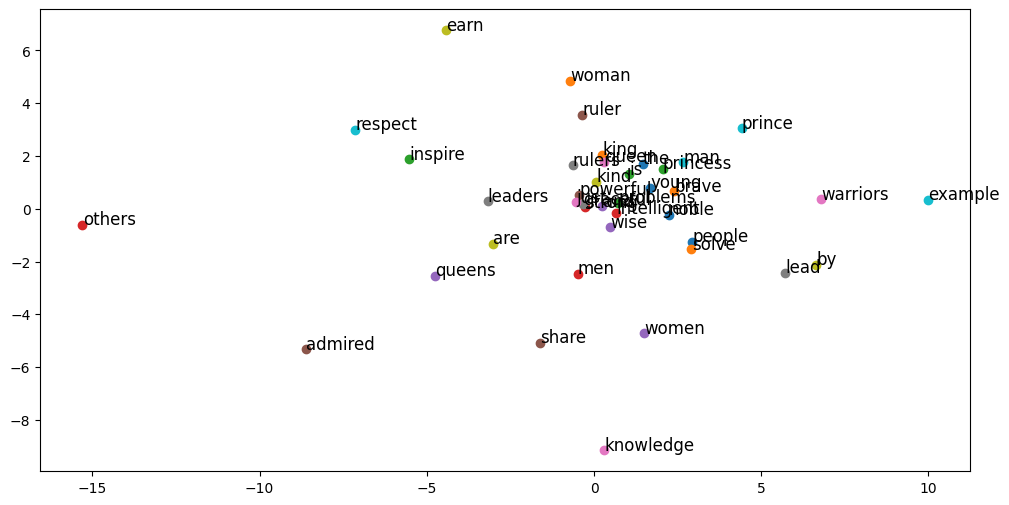

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for word, idx in word2idx.items():
  x, y = reduced_embeddings[idx]
  plt.scatter(x, y)
  plt.text(x + 0.01, y + 0.01, word, fontsize=12)
plt.show()